In [ ]:
%pip install xgboost

# DATA
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, chi2_contingency

# GRAFICOS
import matplotlib.pyplot as plt
import seaborn as sns

# DATA PREPROCESSING
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# MODELOS
import sklearn.linear_model as lm
from sklearn.linear_model import LogisticRegression                    
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier

# METRICAS DE CLASIFICACIÓN
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve                        
import joblib

#FUNCIONES PROPIAS
from functions import data_quality_analysis, plot_descriptive, outlier_detection, evaluate_model

import warnings
warnings.filterwarnings('ignore')

Defaulting to user installation because normal site-packages is not writeable


# Carga y unión de archivos 

In [2]:
df_usage_logs = pd.read_csv("usage_logs.csv")
df_users = pd.read_csv("users.csv")
df_churn_labels = pd.read_csv("churn_labels.csv")

In [3]:
df_usage_logs.sample(5)

,user_id,date,actions_performed,time_spent_minutes,documents_created,logins
5716,user_132,2023-07-26,8,5.563637,1,0
2231,user_53,2023-06-22,6,9.187086,1,2
6926,user_157,2023-07-17,5,36.265871,1,0
6209,user_142,2023-07-14,6,15.245835,1,0
6620,user_151,2023-08-30,4,19.230103,0,1


In [4]:
df_usage_logs.shape

(8754, 6)

In [5]:
df_users.sample(5)

,user_id,signup_date,plan_type,country
161,user_162,2023-07-06,free,DE
144,user_145,2023-03-31,free,DE
170,user_171,2023-01-28,premium,CA
183,user_184,2023-01-27,basic,DE
139,user_140,2023-05-22,free,IN


In [6]:
df_users.shape

(200, 4)

In [7]:
df_churn_labels.sample(5)

,user_id,churned
171,user_172,0
150,user_151,0
168,user_169,0
118,user_119,0
184,user_185,0


In [8]:
df_churn_labels.shape

(200, 2)

In [9]:
# Valores duplicados antes del cruce
print(df_usage_logs.duplicated(subset = 'user_id').sum())   
print(df_users.duplicated(subset = 'user_id').sum())   
print(df_churn_labels.duplicated(subset = 'user_id').sum()) 

8554
0
0


In [10]:
# Cruce de las 3 tablas, indicando sufijos.
df_merged = df_usage_logs.\
merge(df_users, validate = "many_to_one").\
merge(df_churn_labels, validate = "many_to_one", on = "user_id", suffixes = ["_users", "_churn_labels"])

In [11]:
df_merged.sample(5)

,user_id,date,actions_performed,time_spent_minutes,documents_created,logins,signup_date,plan_type,country,churned
150,user_4,2023-06-13,3,10.115632,0,0,2023-01-15,free,CA,0
7170,user_162,2023-06-22,4,12.358017,2,2,2023-07-06,free,DE,0
394,user_10,2023-07-20,3,13.221294,1,1,2023-05-02,premium,AU,0
2828,user_66,2023-07-07,11,28.931297,3,1,2023-01-08,premium,AU,0
3333,user_78,2023-06-29,7,4.099239,0,0,2023-01-04,premium,CA,0


In [12]:
# Valores duplicados después del cruce.
df_merged.duplicated().sum()

0

In [13]:
print('Numero de filas: {0}'.format(df_merged.shape[0]))
print('Numero de columnas: {0}'.format(df_merged.shape[1]))

Numero de filas: 8754
Numero de columnas: 10


# Análisis de Calidad de Datos

In [14]:
# Rango de fechas del dataset
df_merged['signup_date'] = pd.to_datetime(df_merged['signup_date'], format= "%Y-%m-%d").dt.date
df_merged['date'] = pd.to_datetime(df_merged['date'], format= "%Y-%m-%d").dt.date
df_merged.date.min(), df_merged.date.max()

(datetime.date(2023, 6, 1), datetime.date(2023, 8, 31))

In [16]:
calidad = data_quality_analysis(df_merged)
print(calidad.shape)
calidad.head(10)

(10, 20)


,tipo,nulos,porc_nulos,ceros,porc_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,dist_IQR,limit_inf,limit_sup,outliers
actions_performed,int64,0,0.0,61,0.006968,8754.0,NaN,NaN,NaN,5.033927,2.25332,0.0,3.0,5.0,6.0,16.0,3.0,-1.5,10.5,138
documents_created,int64,0,0.0,3211,0.366804,8754.0,NaN,NaN,NaN,0.990062,0.979286,0.0,0.0,1.0,2.0,8.0,2.0,-3.0,5.0,4
logins,int64,0,0.0,3285,0.375257,8754.0,NaN,NaN,NaN,0.981494,0.988741,0.0,0.0,1.0,2.0,6.0,2.0,-3.0,5.0,2
churned,int64,0,0.0,8624,0.985150,8754.0,NaN,NaN,NaN,0.01485,0.120961,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,130
time_spent_minutes,float64,0,0.0,0,0.000000,8754.0,NaN,NaN,NaN,20.001111,14.050456,0.064379,9.562531,16.854741,27.082059,148.039516,17.519528,-16.71676,53.361351,249
user_id,object,0,0.0,0,0.000000,8754,200,user_10,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
date,object,0,0.0,0,0.000000,8754,92,2023-08-28,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
signup_date,object,0,0.0,0,0.000000,8754,120,2023-07-09,344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
plan_type,object,0,0.0,0,0.000000,8754,3,basic,3520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
country,object,0,0.0,0,0.000000,8754,7,DE,1617,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [17]:
# Se observa la cantidad de variables de cada tipo que tiene                                 LO SACARÍA
calidad.tipo.value_counts()

object     5
int64      4
float64    1
Name: tipo, dtype: int64

1- No hay valores faltantes

2- Se deben eliminar outliers ya que el modelo de Regresión Logística por ser un modelo lineal es sensible a ellos

3- El target se corrobora que es numérico

4- Codificar variables categórica 'plan_type' y 'country'

5- Hay datos en una ventana temporal de 3 meses (de Junio a Agosto)


<Figure size 800x800 with 0 Axes>

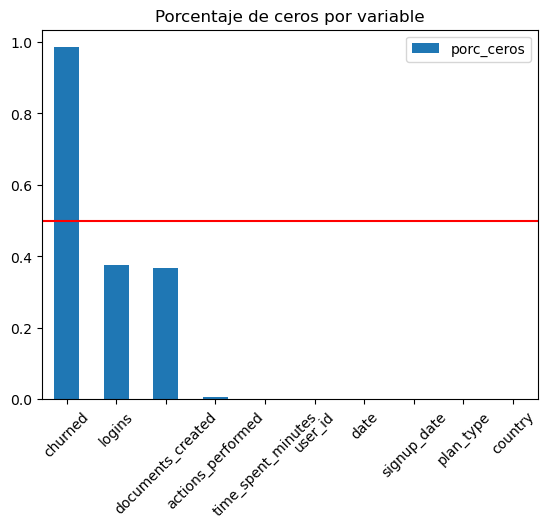

In [18]:
plt.figure(figsize=(8, 8))
calidad.sort_values('porc_ceros', ascending=False).loc[:, ['porc_ceros']].head(20).plot(kind='bar')
plt.axhline(0.5, color='red')
plt.title('Porcentaje de ceros por variable')
plt.xticks(rotation= 45)
plt.show()

<Figure size 800x800 with 0 Axes>

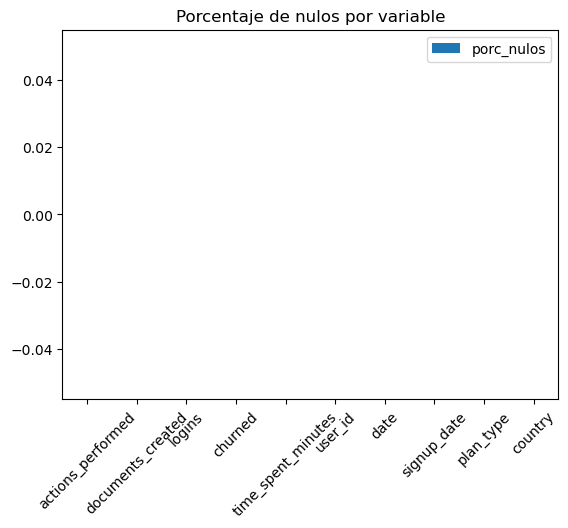

In [19]:
plt.figure(figsize=(8, 8))
calidad.sort_values('porc_nulos', ascending=False).loc[:, ['porc_nulos']].head(20).plot(kind='bar')
plt.title('Porcentaje de nulos por variable')
plt.xticks(rotation= 45)
plt.show()

<Figure size 800x800 with 0 Axes>

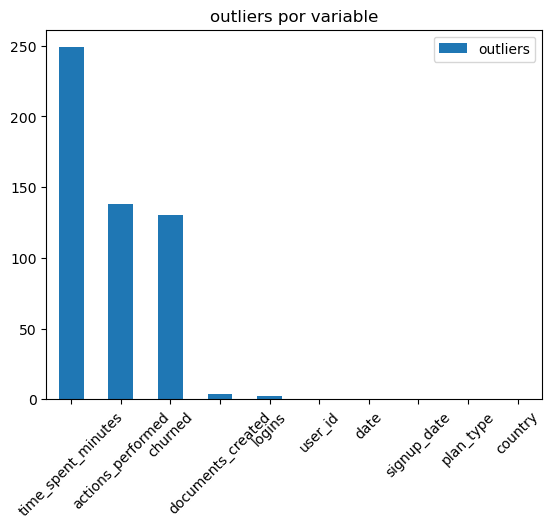

In [20]:
plt.figure(figsize=(8, 8))
calidad.sort_values('outliers', ascending=False).loc[:, ['outliers']].head(20).plot(kind='bar')
plt.title('outliers por variable')
plt.xticks(rotation= 45)
plt.show()

In [21]:
# NO HAY VARIABLES QUE NO ENTREGAN INFORMACION
calidad.loc[(calidad['std']==0)|(calidad['unique']==1)]

,tipo,nulos,porc_nulos,ceros,porc_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,dist_IQR,limit_inf,limit_sup,outliers


# Análisis Explorarorio Inicial de los Datos

## Análisis Univariado

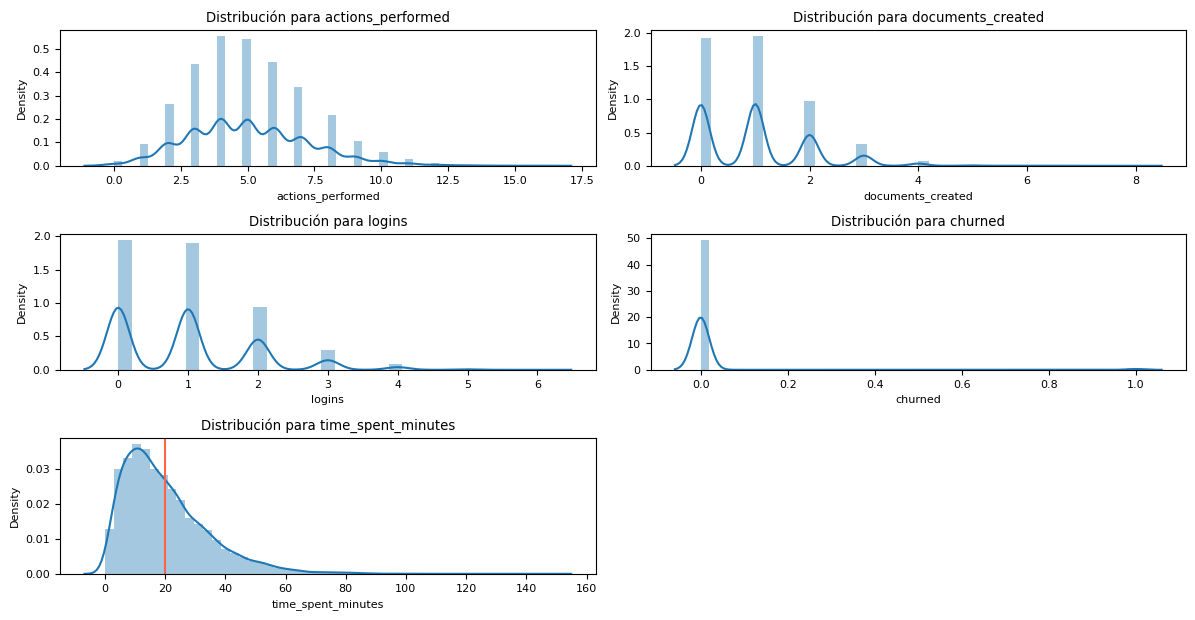

In [ ]:
#Analizamos la distribución de los datos, para familiarizarnos con ellos.
plot_descriptive(calidad, df_merged, calidad.index[:5])

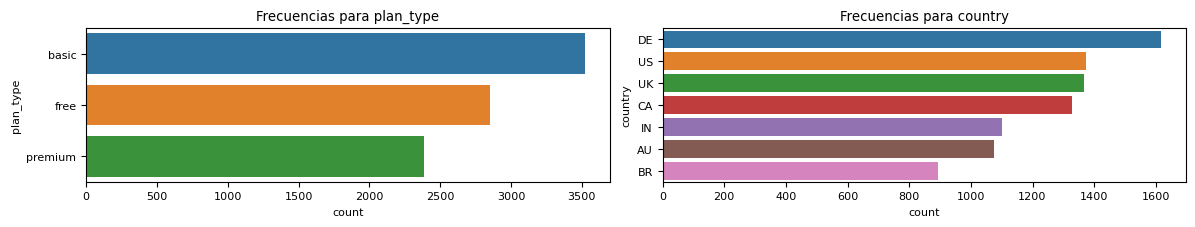

In [24]:
plot_descriptive(calidad, df_merged, calidad.index[-2:])

Se observa claro desbalanceo de clases en el target, lo cuál es bastante normal en problemas de churn

## Multivariado - Correlaciones

In [26]:
numerical_variables = df_merged.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df_merged[numerical_variables].corr()  

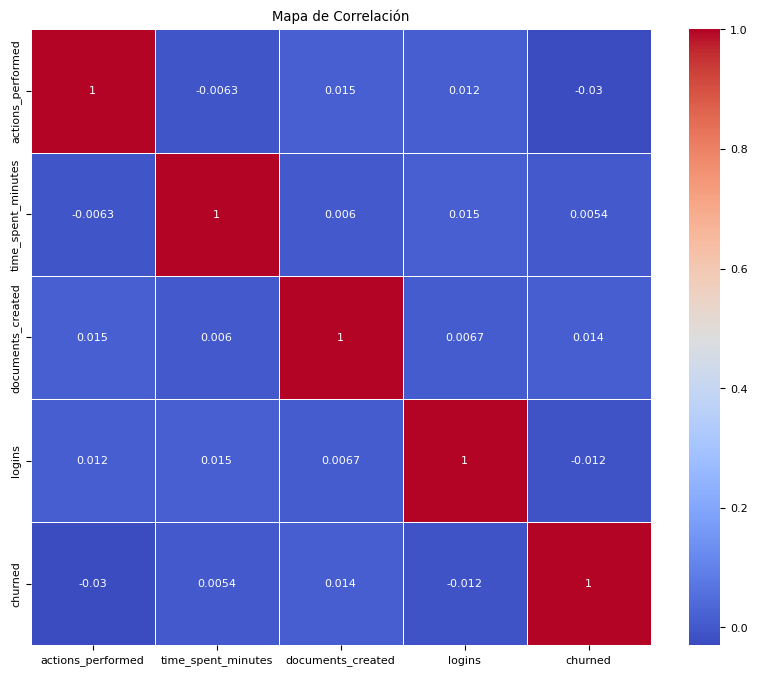

In [27]:
plt.figure(figsize=(10, 8))
sns.heatmap( correlation_matrix , annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Mapa de Correlación')
plt.show()

# Tratamiento de Outliers

In [29]:
numeric_features = numerical_variables[:-1]

df_clean = outlier_detection(df_merged, numeric_features)
df_clean.head()

,user_id,date,actions_performed,time_spent_minutes,documents_created,logins,signup_date,plan_type,country,churned
0,user_1,2023-06-27,6,9.913891,1,0,2023-04-13,free,BR,0
1,user_1,2023-08-17,1,42.932974,2,3,2023-04-13,free,BR,0
2,user_1,2023-07-22,3,7.752782,1,0,2023-04-13,free,BR,0
3,user_1,2023-06-22,2,9.418014,0,2,2023-04-13,free,BR,0
5,user_1,2023-07-19,5,11.467805,0,0,2023-04-13,free,BR,0


In [30]:
print(f"Número de filas resultantes: {df_clean.shape[0]}")
print(f"Número de columnas: {df_clean.shape[1]}")

Número de filas resultantes: 8363
Número de columnas: 10


# Features Engineering

In [31]:
# Recordemos el dataset a partir del cuál agregaremos la data a nivel 'user_id' 
df_clean.head()

,user_id,date,actions_performed,time_spent_minutes,documents_created,logins,signup_date,plan_type,country,churned
0,user_1,2023-06-27,6,9.913891,1,0,2023-04-13,free,BR,0
1,user_1,2023-08-17,1,42.932974,2,3,2023-04-13,free,BR,0
2,user_1,2023-07-22,3,7.752782,1,0,2023-04-13,free,BR,0
3,user_1,2023-06-22,2,9.418014,0,2,2023-04-13,free,BR,0
5,user_1,2023-07-19,5,11.467805,0,0,2023-04-13,free,BR,0


In [ ]:
# Definición de un 'snapshot_date' que nos permitirá separar los datos "pasados" que emplearemos para entrenar de los datos
# "futuros" que nos permitirán redefinir el target y evitar data leakage

future_window = 5 

snapshot_date = df_clean['date'].max() - pd.Timedelta(days= future_window)
df_past = df_clean[df_clean['date'] <= snapshot_date]

df_future = df_clean[
    (df_clean['date'] > snapshot_date) & 
    (df_clean['date'] <= snapshot_date + pd.Timedelta(days=future_window))]


# Redefinición del target --> usuarios sobre los que quiero predecir churn
active_users = df_future['user_id'].unique()
df_target = df_past[['user_id']].drop_duplicates()
df_target['churned'] = df_target['user_id'].apply(lambda x: 0 if x in active_users else 1)


In [33]:
# Features Engineering. Agrupamiento a nivel 'user_id' en base a la información pasada

# Fecha de referencia - última del dataset
reference_date = df_past['date'].max()

# Agrupación
df_user = df_past.groupby('user_id').agg({
    'actions_performed': ['sum', 'mean'],
    'time_spent_minutes': ['sum', 'mean'],
    'documents_created': ['sum'],
    'logins': ['sum'],
    'date': ['max','nunique'],
    'signup_date': ['min'],
    'plan_type': lambda x: x.mode()[0],
    'country': lambda x: x.mode()[0]
})



# Aplanar columnas
df_user.columns = ['_'.join(col).strip() for col in df_user.columns]

# Renombrar algunas
df_user = df_user.rename(columns={
    'date_max': 'last_activity_date',
    'date_nunique': 'active_days',
    'signup_date_min': 'signup_date',
    'plan_type_<lambda>': 'plan_type',
    'country_<lambda>': 'country'})

# Recency
df_user['days_since_last_activity'] = (reference_date - df_user['last_activity_date']).dt.days

# Tenure
df_user['days_since_signup'] = (reference_date - df_user['signup_date']).dt.days

# Features derivadas
df_user['actions_per_day'] = df_user['actions_performed_sum'] / (df_user['active_days'] + 1)
df_user['time_per_login'] = df_user['time_spent_minutes_sum'] / (df_user['logins_sum'] + 1)

df_user = df_user.drop(columns= ['last_activity_date', 'signup_date', 'time_spent_minutes_sum', 'actions_performed_sum', 'logins_sum', 'active_days' ])

In [34]:
# union del dataset resultante en el paso anterior con el que contiene el target redefinido
df_user = df_user.reset_index()
df_user = df_user.merge(df_target, on='user_id', how='left')
df_user.set_index('user_id', inplace = True)

print(df_user['churned'].value_counts(dropna=False))

# rellenaremos con ceros si hay valores NaN producto del merge
if df_user['churned'].isna().sum() > 0:
    df_user['churned'] = df_user['churned'].fillna(0)

0    185
1     15
Name: churned, dtype: int64


In [35]:
# dataframe resultante
df_user.head()

,actions_performed_mean,time_spent_minutes_mean,documents_created_sum,plan_type,country,days_since_last_activity,days_since_signup,actions_per_day,time_per_login,churned
user_id,,,,,,,,,,
user_1,4.829787,16.801341,48,free,BR,2,135,4.729167,12.945295,1
user_10,4.854839,18.980994,69,premium,AU,0,116,4.777778,25.583079,0
user_100,4.956522,19.329617,49,free,AU,0,81,4.851064,24.031415,0
user_101,4.718750,17.838440,26,basic,AU,1,223,4.575758,15.427840,0
user_102,4.868421,19.638082,41,basic,BR,0,193,4.743590,24.072488,0


In [36]:
print(f"Número de filas: {df_user.shape[0]}")
print(f"Número de columnas: {df_user.shape[1]}")

Número de filas: 200
Número de columnas: 10


# Análisis de Calidad de los datos

In [37]:
# chequeamos la calidad de los datos del dataframe resultante
calidad = data_quality_analysis(df_user)
print(calidad.shape)
calidad.head(10)

(10, 20)


,tipo,nulos,porc_nulos,ceros,porc_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,dist_IQR,limit_inf,limit_sup,outliers
documents_created_sum,int64,0,0.0,0,0.000,200.0,NaN,NaN,NaN,38.8,14.062674,12.0,27.0,39.0,49.0,71.0,22.0,-6.0,82.0,0
days_since_last_activity,int64,0,0.0,88,0.440,200.0,NaN,NaN,NaN,1.445,2.075697,0.0,0.0,1.0,2.0,11.0,2.0,-3.0,5.0,9
days_since_signup,int64,0,0.0,0,0.000,200.0,NaN,NaN,NaN,139.61,58.707758,38.0,87.75,142.0,189.25,237.0,101.5,-64.5,341.5,0
churned,int64,0,0.0,185,0.925,200.0,NaN,NaN,NaN,0.075,0.264052,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,15
actions_performed_mean,float64,0,0.0,0,0.000,200.0,NaN,NaN,NaN,4.921881,0.352409,3.966667,4.715821,4.909091,5.160714,6.222222,0.444893,4.048482,5.828054,5
time_spent_minutes_mean,float64,0,0.0,0,0.000,200.0,NaN,NaN,NaN,18.730252,2.098151,11.579257,17.334551,18.60103,20.093845,25.02722,2.759294,13.19561,24.232786,6
actions_per_day,float64,0,0.0,0,0.000,200.0,NaN,NaN,NaN,4.78479,0.348938,3.83871,4.573975,4.781929,5.017503,6.0,0.443528,3.908682,5.682796,4
time_per_login,float64,0,0.0,0,0.000,200.0,NaN,NaN,NaN,19.182604,3.841836,11.163114,16.387885,18.968644,21.38192,37.540831,4.994035,8.896833,28.872972,3
plan_type,object,0,0.0,0,0.000,200,3,basic,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
country,object,0,0.0,0,0.000,200,7,DE,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


# Tratamiento de Outliers

In [38]:
# eliminamos outliers presentes
numeric_features = df_user.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('churned')

In [39]:
df_clean_user = outlier_detection(df_user, numeric_features)
df_clean_user.head()

,actions_performed_mean,time_spent_minutes_mean,documents_created_sum,plan_type,country,days_since_last_activity,days_since_signup,actions_per_day,time_per_login,churned
user_id,,,,,,,,,,
user_1,4.829787,16.801341,48,free,BR,2,135,4.729167,12.945295,1
user_10,4.854839,18.980994,69,premium,AU,0,116,4.777778,25.583079,0
user_100,4.956522,19.329617,49,free,AU,0,81,4.851064,24.031415,0
user_101,4.718750,17.838440,26,basic,AU,1,223,4.575758,15.427840,0
user_102,4.868421,19.638082,41,basic,BR,0,193,4.743590,24.072488,0


# Análisis Exploratorio Avanzado de los Datos

## Análisis Univariado

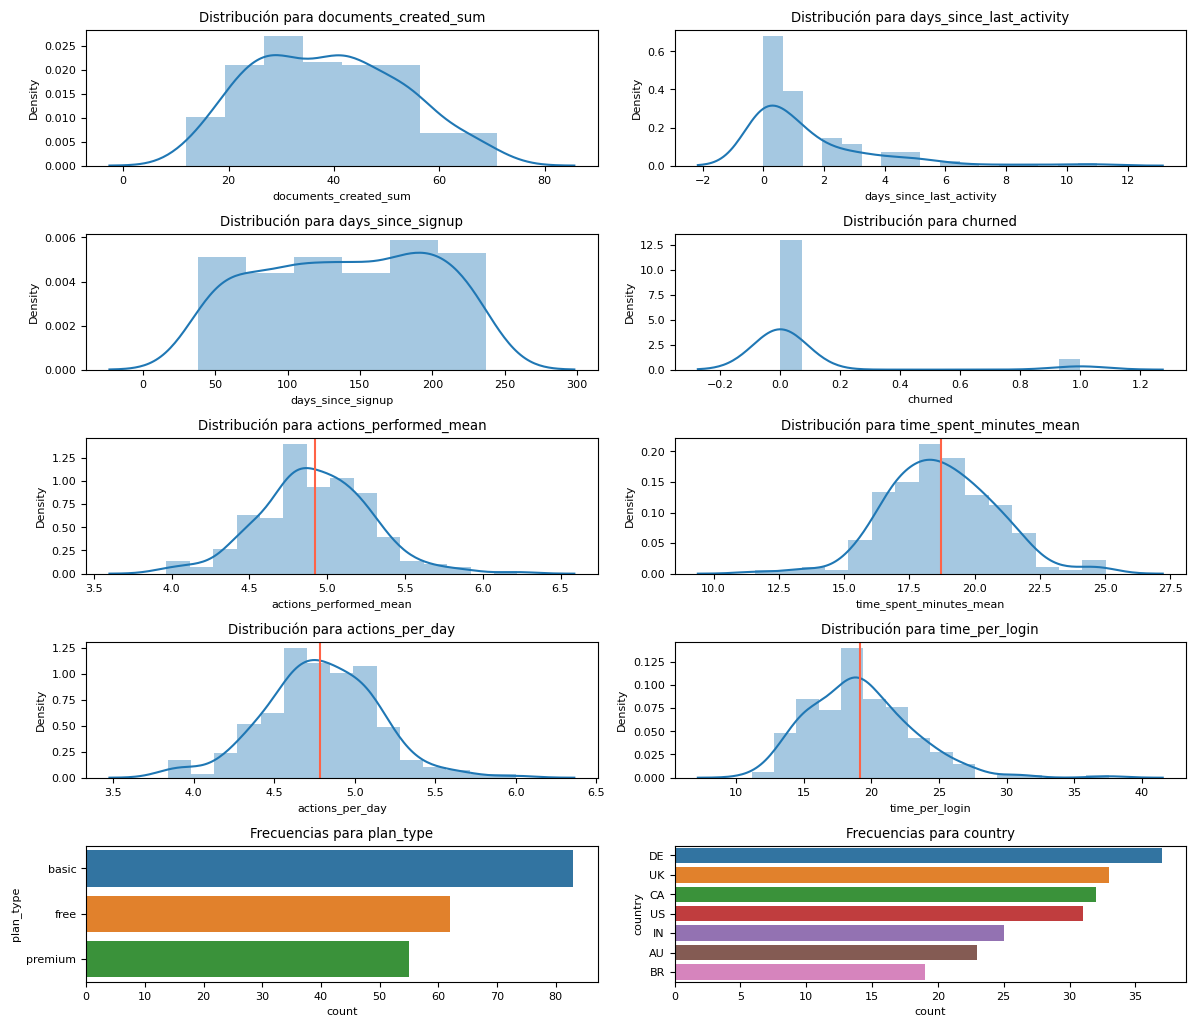

In [40]:
plot_descriptive(calidad, df_user, calidad.index)

## Análisis Bivariado

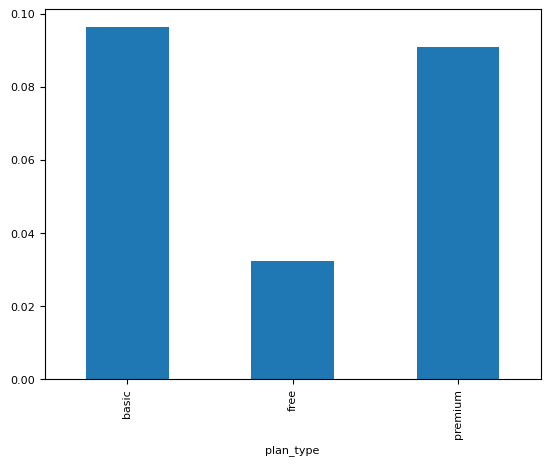

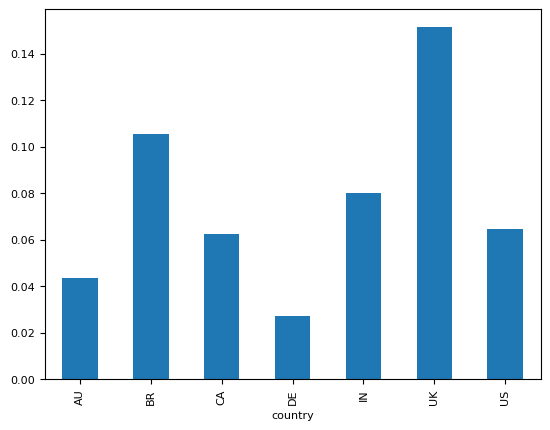

In [41]:
categorical_features = df_user.select_dtypes(include=['object']).columns.tolist()

for i in categorical_features:
    dfi = df_user.groupby(i).churned.mean()
    dfi.plot(kind='bar')
    plt.show()


 ### Correlaciones

Correlación chi-cuadrado entre variables categóricas y Churn

In [42]:
for feature in categorical_features:
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df_user[feature], df_user['churned']))
    print(f"Chi-cuadrado entre {feature} y Churn: {chi2:.2f}, p-value: {p:.4f}")

Chi-cuadrado entre plan_type y Churn: 2.38, p-value: 0.3041
Chi-cuadrado entre country y Churn: 4.72, p-value: 0.5798


Prueba de hipótesis
Asumiendo un umbral para evaluar la significancia estadística del resultado 'alfa = 5%', se observa que ninguna de las dos features categóricas analizadas posee una asociación significativa con el target

Correlación de Pearson entre las variables numéricas y Churn

<Axes: >

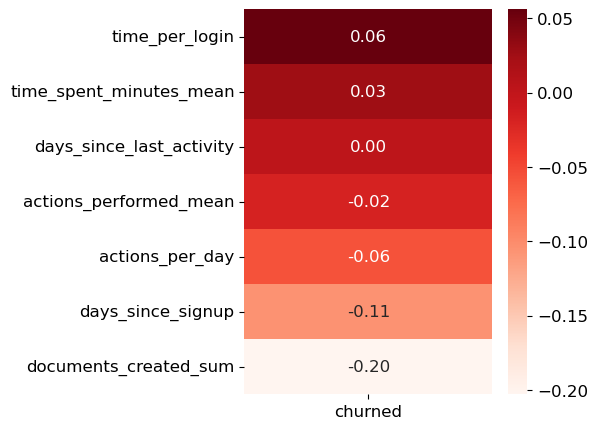

In [43]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(4, 5))
sns.heatmap(df_user.corr().loc[:, ['churned']].sort_values('churned', ascending=False).iloc[1:], cmap='Reds', annot=True, fmt= '.2f')

La correlación de Pearson permite medir el grado de correlación entre features numéricas asumiendo que existe una relación leneal entre ellas. En este caso, se observa las correlaciones de las features contra el target y se evidencia que hay dos que muestran una muy leve influencia en el churn, una leve influencia inversa, a saber: 'documents_created_sum' y 'days_since_signup'

## Multivariado - Correlaciones

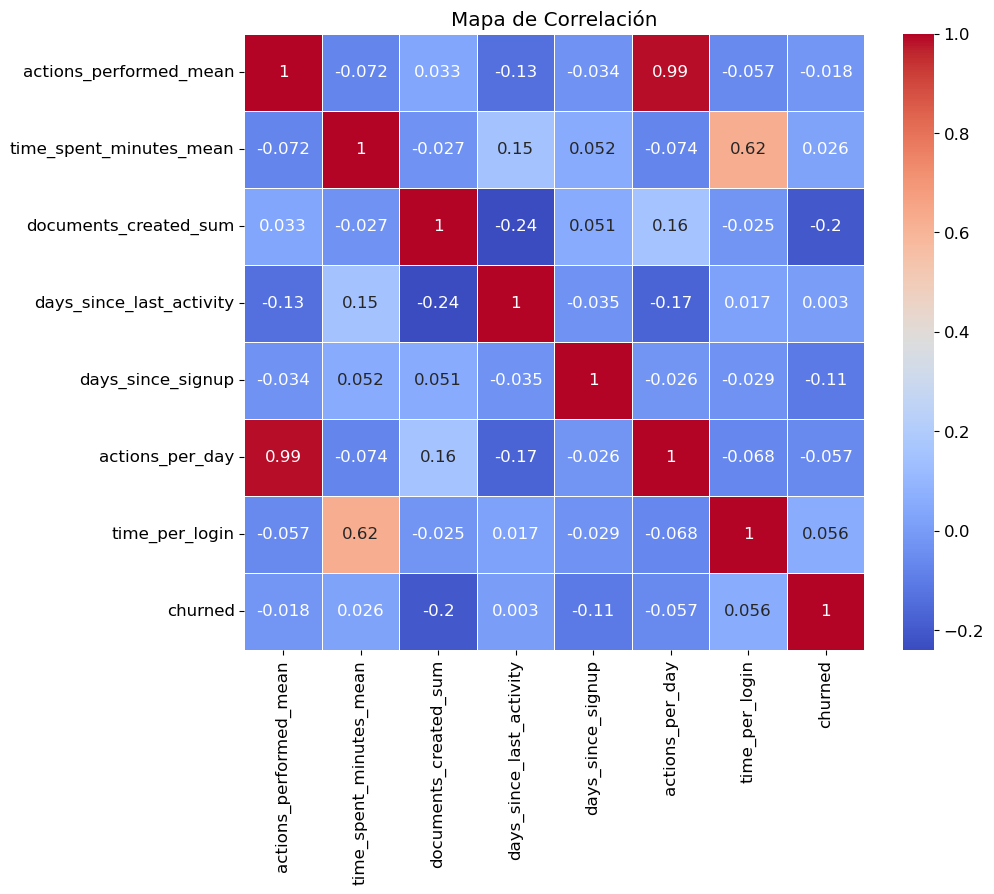

In [44]:
numerical_variables = df_user.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = df_user[numerical_variables].corr() 

plt.figure(figsize=(10, 8))
sns.heatmap( correlation_matrix , annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Mapa de Correlación')
plt.show()

Se observa presencia de colinealidad por lo que se opta eliminar la feature: 'actions_performed_mean' dado que es la que tiene menor influencia en el target

In [45]:
df_user.drop(columns= 'actions_performed_mean', axis= 1, inplace= True)

# Codificación de Variables Categóricas

In [46]:
cols_to_encode = ['plan_type', 'country']

df_encoded = pd.get_dummies(df_user.loc[:, cols_to_encode], drop_first = True).astype(int)
df_final = pd.concat([df_user.drop(cols_to_encode, axis = 1), df_encoded], axis =1)
df_final.head()

,time_spent_minutes_mean,documents_created_sum,days_since_last_activity,days_since_signup,actions_per_day,time_per_login,churned,plan_type_free,plan_type_premium,country_BR,country_CA,country_DE,country_IN,country_UK,country_US
user_id,,,,,,,,,,,,,,,
user_1,16.801341,48,2,135,4.729167,12.945295,1,1,0,1,0,0,0,0,0
user_10,18.980994,69,0,116,4.777778,25.583079,0,0,1,0,0,0,0,0,0
user_100,19.329617,49,0,81,4.851064,24.031415,0,1,0,0,0,0,0,0,0
user_101,17.838440,26,1,223,4.575758,15.427840,0,0,0,0,0,0,0,0,0
user_102,19.638082,41,0,193,4.743590,24.072488,0,0,0,1,0,0,0,0,0


In [47]:
print(f"Número de filas: {df_final.shape[0]}")
print(f"Número de columnas: {df_final.shape[1]}")

Número de filas: 200
Número de columnas: 15


# Modelamiento

In [48]:
RANDOM_STATE = 42

In [49]:
# Separaramos features del target
X = df_final.drop('churned', axis=1) 
y = df_final['churned']

In [ ]:
# Separaramos los datos en entrenamiento y prueba teniendo en cuenta su estratificación
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state= RANDOM_STATE, stratify=y )

## Regresión Logística

In [51]:
# Escalado de características
scaler = StandardScaler()

numeric_features = df_final.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('churned')

for num_feature in numeric_features:
    X_train_scaled = scaler.fit_transform(X_train[[num_feature]])
    X_test_scaled = scaler.transform(X_test[[num_feature]])

La lógica a continuación es optimizar hiperparámetros implementando primero RandomizedSearchCV para poder barrer sobre una abanico más amplio de combinaciones de hiperparámetros que nos permitan orientarnos un poco, para seguidamente implementar GridSearchCV y realizar una búsqueda exahustiva entorno a las mejores combinaciones resultantes que arrojó el modelo anterior

In [52]:
logistic_regression_model = LogisticRegression(class_weight= 'balanced', random_state= RANDOM_STATE)

In [ ]:
# optimización de hiperparámetros con RandomizedSearchCV
parameters_log_reg = {  'C': np.linspace(0.005, 0.1, 5),  
                'penalty': ['l1', 'l2', 'elasticnet', None],
                'solver': ['lbfgs', 'liblinear']}



logistic_regression_randomsearch = RandomizedSearchCV( logistic_regression_model,
                                                      parameters_log_reg,
                                                      random_state = RANDOM_STATE,
                                                      cv = 5,
                                                      scoring = 'recall',
                                                      n_jobs= -1).fit(X_train_scaled, y_train)


print(logistic_regression_randomsearch.best_params_)

In [ ]:
# optimización de hiperparámetros con GridSearchCV
param_grid_log_reg =  {  'C': np.linspace(0.005, 0.1, 5),  
                'penalty': ['l2'],                
                'solver': ['liblinear']} 



%%time
logistic_regression_gridsearch = GridSearchCV( logistic_regression_model,
                                              param_grid_log_reg,
                                              cv = 5,
                                              scoring = 'recall',
                                              n_jobs= -1).fit(X_train_scaled, y_train)


print(logistic_regression_gridsearch.best_params_)

CPU times: total: 62.5 ms
Wall time: 145 ms


In [59]:
# el mejor modelo resultante
best_logistic_regression = logistic_regression_gridsearch.best_estimator_
best_logistic_regression

LogisticRegression(C=0.005, class_weight='balanced', random_state=42,
                   solver='liblinear')

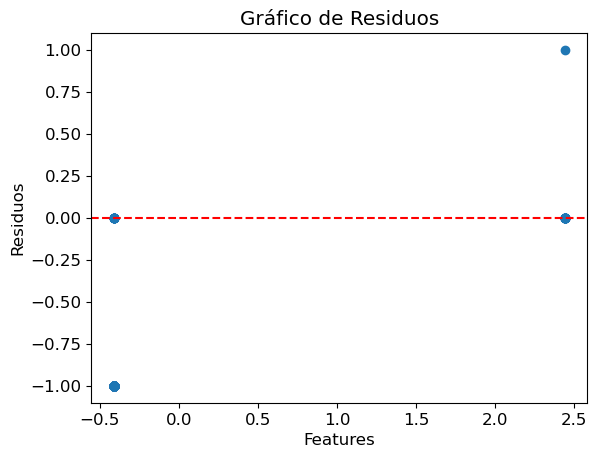

In [60]:
# Validación del supuesto de linealidad --> muy pocos datos, no se puede concluir
y_pred_train = best_logistic_regression.predict(X_train_scaled)

residuals = y_train - y_pred_train

plt.figure()
plt.scatter(X_train_scaled, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Gráfico de Residuos")
plt.xlabel("Features")
plt.ylabel("Residuos")
plt.show()

## Random Forest

In [62]:
random_forest_model =   RandomForestClassifier(
                        random_state=RANDOM_STATE,
                        class_weight='balanced',
                        n_jobs=-1 
                    )

In [ ]:
# optimización de hiperparámetros con RandomizedSearchCV
parameters_random_forest = {  'n_estimators': range(50, 150, 10),  
                            'max_features': [None, 'sqrt', 'log2'],
                            'max_depth': range(1, 10),
                            'criterion':['gini', 'entropy']
                        }



random_forest_randomsearch = RandomizedSearchCV( random_forest_model,
                                                      parameters_random_forest,
                                                      random_state = RANDOM_STATE,
                                                      cv = 5,
                                                      scoring = 'recall',
                                                      n_jobs= -1).fit(X_train, y_train)


print(random_forest_randomsearch.best_params_)

In [ ]:
# optimización de hiperparámetros con GridSearchCV
param_grid_random_forest= {'n_estimators': range(100, 140, 10), 
                           'max_depth': range(1, 5),
                           'max_features': ['log2'],
                           'criterion': ['entropy'] 
                        }



%%time
random_forest_gridsearch = GridSearchCV( random_forest_model,
                                          param_grid_random_forest,
                                          cv = 5,
                                          scoring = 'recall',
                                          n_jobs= -1).fit(X_train, y_train)


print(random_forest_gridsearch.best_params_)

CPU times: total: 922 ms
Wall time: 21.9 s


In [69]:
# el mejor modelo resultante
best_random_forest = random_forest_gridsearch.best_estimator_
best_random_forest

RandomForestClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=1, max_features='log2', n_jobs=-1,
                       random_state=42)

## XGBoost

In [70]:
xgboost_model = xgb.XGBClassifier(
                        random_state=RANDOM_STATE,
                        scale_pos_weight= (y_train.value_counts()[0] / y_train.value_counts()[1])
                    )

In [ ]:
# optimización de hiperparámetros con RandomizedSearchCV
parameters_xgboost = {'n_estimators': range(20, 150, 10),  
                            'max_depth': range(1, 10),
                            'learning_rate': np.linspace(0.1, 2, 10),
                            'eval_metric':['logloss', 'auc', 'error']
                        }



xgboost_randomsearch = RandomizedSearchCV( xgboost_model,
                                          parameters_xgboost,
                                          random_state = RANDOM_STATE,
                                          cv = 5,
                                          scoring = 'recall',
                                          n_jobs= -1).fit(X_train, y_train)


print(xgboost_randomsearch.best_params_)

In [ ]:
# optimización de hiperparámetros con GridSearchCV
param_grid_xgboost = {'n_estimators': range(50, 120, 10),  
                            'max_depth': range(1, 5),
                            'learning_rate': np.linspace(0.1, 1, 10),
                            'eval_metric':['auc']
                        }



%%time
xgboost_gridsearch = GridSearchCV( xgboost_model,
                                  param_grid_xgboost,
                                  cv = 5,
                                  scoring = 'recall',
                                  n_jobs= -1).fit(X_train, y_train)


print(xgboost_gridsearch.best_params_)

CPU times: total: 6.31 s
Wall time: 45.2 s


In [77]:
# el mejor modelo resultante
best_xgboost = xgboost_gridsearch.best_estimator_
best_xgboost

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=1,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, ...)

# Evaluación de Modelos

In [78]:
# despliegue de reporte y visualizaciones de métricas
results = []
results_proba = []

model_names= ['LogisticRegression', 'RandomForest', 'XGBoost']      
best_models= [best_logistic_regression, best_random_forest, best_xgboost]      

for name, model in zip(model_names, best_models):
    if name == 'LogisticRegression':
        precision, recall, f1, roc_auc, prc_auc, y_proba = evaluate_model(model, X_test_scaled, y_test)
    else:
        precision, recall, f1, roc_auc, prc_auc, y_proba = evaluate_model(model, X_test, y_test)
    
    results.append(pd.DataFrame({"Model": [name], "Precisión": [precision], "Recall": [recall], "f1 score": [f1], "roc auc": [roc_auc], "prc auc": [prc_auc] }))
    results_proba.append(pd.DataFrame({"Model": [name], "y_proba": [y_proba], "roc auc": [roc_auc], "prc auc": [prc_auc] }))

results = pd.concat(results).reset_index(drop=True)
results_proba = pd.concat(results_proba).reset_index(drop=True)

# Mostrar resultados
print("\nResultados de evaluación de modelos:")
results.head(3)


Resultados de evaluación de modelos:


,Model,Precisión,Recall,f1 score,roc auc,prc auc
0,LogisticRegression,0.06,0.67,0.11,0.43,0.07
1,RandomForest,0.25,0.33,0.29,0.56,0.40
2,XGBoost,0.09,0.33,0.14,0.66,0.41


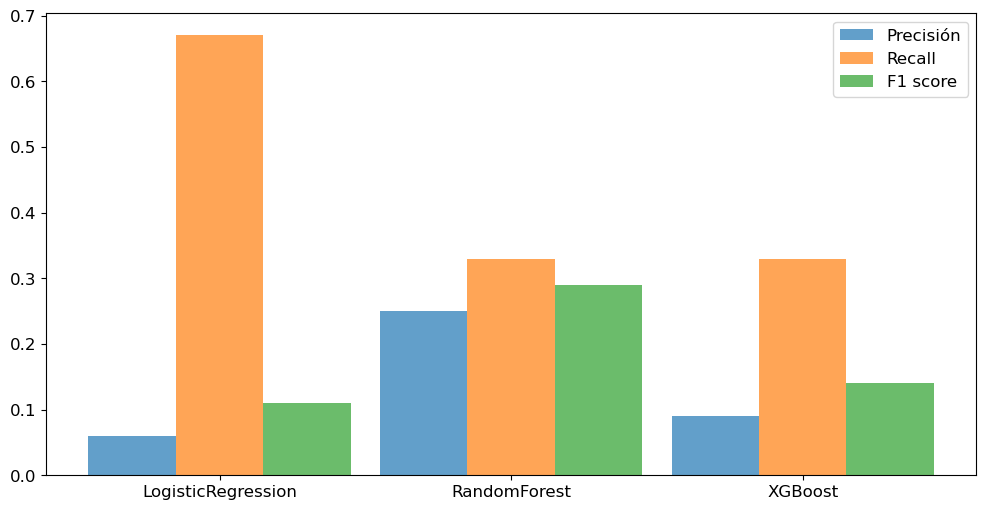

In [79]:
model_names= ['LogisticRegression', 'RandomForest', 'XGBoost'] 

co= np.arange(len(model_names))
an = 0.30

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(co - an, results["Precisión"], an, label="Precisión", alpha=0.7)
ax.bar(co , results["Recall"], an, label="Recall", alpha=0.7)
ax.bar(co + an, results["f1 score"], an, label="F1 score", alpha=0.7)
ax.set_xticks(co)
ax.set_xticklabels(model_names)
ax.legend()

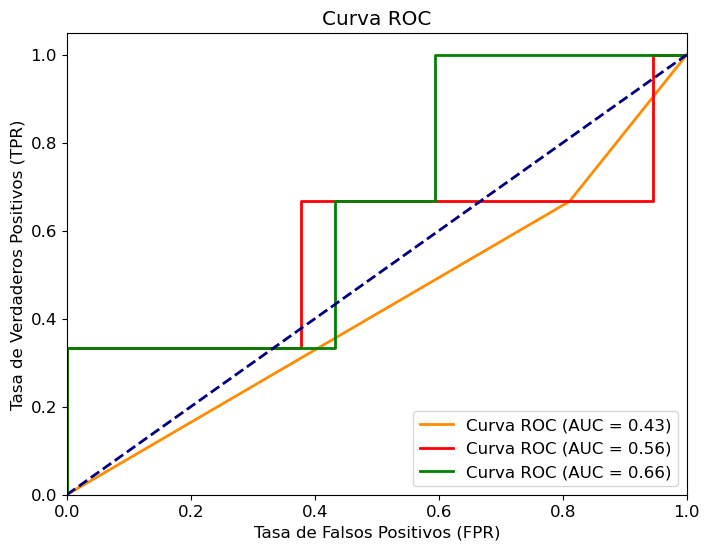

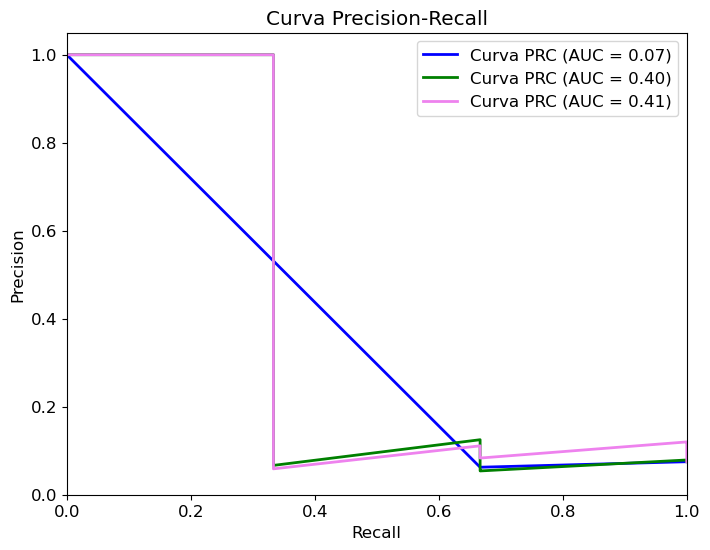

In [80]:
# Calcular la curva ROC
fpr_log_reg, tpr_log_reg, thresholds_roc_log_reg = roc_curve(y_test, results_proba.loc[0, 'y_proba'])
fpr_random_forest, tpr_random_forest, thresholds_roc_random_forest = roc_curve(y_test, results_proba.loc[1, 'y_proba'])
fpr_xgboost, tpr_xgboost, thresholds_roc_xgboost = roc_curve(y_test, results_proba.loc[2, 'y_proba'])

# Calcular la curva PRC
precision_log_reg, recall_log_reg, thresholds_prc_log_reg = precision_recall_curve(y_test, results_proba.loc[0, 'y_proba'])
precision_random_forest, recall_random_forest, thresholds_prc_random_forest = precision_recall_curve(y_test, results_proba.loc[1, 'y_proba'])
precision_xgboost, recall_xgboost, thresholds_prc_xgboost = precision_recall_curve(y_test, results_proba.loc[2, 'y_proba'])

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_log_reg, tpr_log_reg, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % results_proba.loc[0, 'roc auc'])
plt.plot(fpr_random_forest, tpr_random_forest, color='red', lw=2, label='Curva ROC (AUC = %0.2f)' % results_proba.loc[1, 'roc auc'])
plt.plot(fpr_xgboost, tpr_xgboost, color='green', lw=2, label='Curva ROC (AUC = %0.2f)' % results_proba.loc[2, 'roc auc'])
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc='lower right')

# Graficar la curva PRC
plt.figure(figsize=(8, 6))
plt.plot(recall_log_reg, precision_log_reg, color='blue', lw=2, label='Curva PRC (AUC = %0.2f)' % results_proba.loc[0, 'prc auc'])
plt.plot(recall_random_forest, precision_random_forest, color='green', lw=2, label='Curva PRC (AUC = %0.2f)' % results_proba.loc[1, 'prc auc'])
plt.plot(recall_xgboost, precision_xgboost, color='violet', lw=2, label='Curva PRC (AUC = %0.2f)' % results_proba.loc[2, 'prc auc'])
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='upper right')

# Mostrar las curvas ROC y PRC
plt.show()

En churn, el costo de retención es bajo (descuento, email, contacto), en tanto que el costo de perder un cliente es alto por lo que es preferible detectar más churn (alto recall) aunque ello implique equivocarse un poco más (baja precisión).
Es decir, en churn, las métricas más relevantes son: Precision-Recall AUC, F1 score y Recall directamente.
En función a los valores arrojados por las métricas y sus visualizaciones asociadas se concluye que ninguno de los tres modelos puede predecir correctamente el churn. Sin embargo, si se debiese optar por uno de ellos, se escoje por tener mejores valores en las métricas recién nombradas, XGBoost.
El más rendimiento de los modelos muy probablemente sea debido a dos factores:
- tamaño del dataset (es muy pequeño)
- pocos casos positivos (casos de churn)

# Selección de Variables

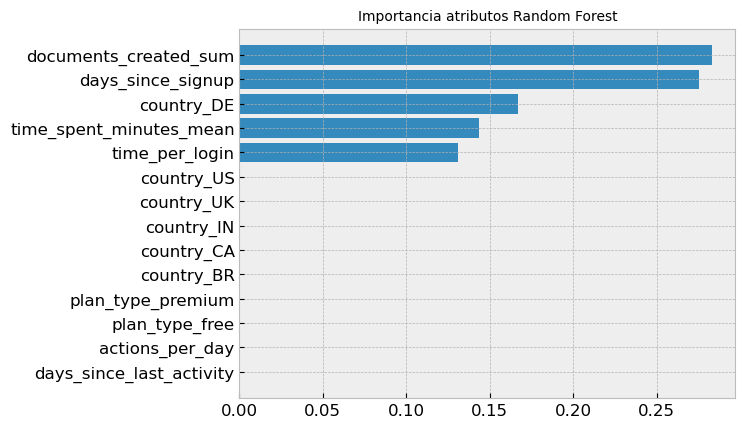

In [81]:
plt.style.use('bmh')

df_importance = pd.DataFrame({
    'atributo': best_xgboost.feature_names_in_,
    'importancia': best_xgboost.feature_importances_
    
}).sort_values(by='importancia', ascending=True)

plt.title('Importancia atributos Random Forest', fontsize=10)
plt.barh(y=df_importance['atributo'], width=df_importance['importancia']);


# Entrenamiento y Guardado del 'Mejor Modelo'

In [82]:
key_feature = df_importance.set_index('atributo').sort_values('importancia', ascending= False).index[:5].to_list()
key_feature

['documents_created_sum',
 'days_since_signup',
 'country_DE',
 'time_spent_minutes_mean',
 'time_per_login']

In [83]:
RANDOM_STATE= 42

# Separar Features del Target
X = df_final[key_feature] 
y = df_final['churned']

# Separar los datos en entrenamiento y prueba (time-based split preferred).
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state= RANDOM_STATE, stratify=y )

In [84]:
xgboost_model_trained = xgb.XGBClassifier(  eval_metric= 'auc',
                                            learning_rate= 0.1,
                                            max_depth= 1,
                                            n_estimators= 50,
                                            random_state=RANDOM_STATE,
                                            scale_pos_weight= (y_train.value_counts()[0] / y_train.value_counts()[1])
                                            ).fit(X_train, y_train)

In [85]:
joblib.dump(xgboost_model_trained, f"{'xgboost'}_model.pkl")